## 1. Import Libraries

In [26]:
# Load libraries
import os, sys #os dung de doc duong dan file, tao xoa thu muc kiem tra file ton tai,sys lay tham so dong lenh vaf dung thoat chuong trinh
from IPython import display # dung cho viec hien hinh anh
import numpy as np
import matplotlib.pyplot as plt # ve do thi 
import pandas as pd # dung su ly du lieu dang bang doc , loc du lieu tu csv excel
import seaborn as sns # ve bieu do nang cao
import joblib # luu va load mo hinh machine learning
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, OrdinalEncoder # chuyen du lieu thanh vecto ,text thanh so, du lieu thu tu
from sklearn.preprocessing import MinMaxScaler, StandardScaler # chuan hoa du lieu tu 0 ->1,Chuẩn hóa dữ liệu theo mean = 0 và std = 1
from sklearn.model_selection import train_test_split # chia va train/ test
from sklearn import model_selection
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
import warnings
from sklearn.model_selection import cross_val_score
%matplotlib inline
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams['figure.dpi'] = 100

warnings.filterwarnings("ignore")

## 2. Load Dataset

In [27]:
data_path = "eda/data/pima-indians-diabetes.csv"

data_names = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age",
    "Outcome"
]

df_dataset = pd.read_csv(data_path, names=data_names)

In [28]:
# shape
print(f'+ Shape : {df_dataset.shape}')
# types
print(f'+ Data Types: \n{df_dataset.dtypes}')
# head, tail
print(f'+ Contents: ')
display.display(df_dataset.head(5))
display.display(df_dataset.tail(5))
# info
df_dataset.info()

+ Shape : (768, 9)
+ Data Types: 
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object
+ Contents: 


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


Ngưỡng sinh lý

In [29]:
physiological_ranges = {
    "Pregnancies": (0, 15),
    "Glucose": (35, 250),
    "BloodPressure": (40, 180),
    "SkinThickness": (7, 100),
    "Insulin": (15, 900),
    "BMI": (10, 60),
    "DiabetesPedigreeFunction": (0, 2.5),
    "Age": (21, 90)
}

xóa dữ liệu trùng lập

In [30]:
duplicated = df_dataset.duplicated()

print(f"Số dòng bị trùng: {duplicated.sum()}")

df_clean = df_dataset.drop_duplicates()

print(f"Kích thước sau khi xóa dòng trùng: {df_clean.shape}")

Số dòng bị trùng: 0
Kích thước sau khi xóa dòng trùng: (768, 9)


In [31]:
from xu_ly_du_lieu import xulydulieu

# Áp dụng
df_final = xulydulieu(df_clean,physiological_ranges)

chia dữ liệu 7/3

In [32]:

X = df_final.drop("Outcome", axis=1)
y = df_final["Outcome"]
seed=1

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=seed, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (532, 8)
Test size: (229, 8)


In [33]:

X_train_sub, X_valid, y_train_sub, y_valid = train_test_split(
    X_train, y_train, test_size=0.3, random_state=seed, stratify=y_train
)

print("Train sub:", X_train_sub.shape)
print("Validation:", X_valid.shape)

Train sub: (372, 8)
Validation: (160, 8)


Linear_Discrimnation

In [34]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

# Khởi tạo mô hình LDA
# (LDA mặc định hoạt động rất tốt mà không cần tinh chỉnh quá nhiều tham số ban đầu)
model_lda = LinearDiscriminantAnalysis()

# Huấn luyện mô hình
model_lda.fit(X_train, y_train)

# Dự đoán trên tập Test
y_pred_lda = model_lda.predict(X_test)

# Đánh giá độ chính xác và ma trận nhầm lẫn
print("LDA Accuracy:", accuracy_score(y_test, y_pred_lda))

cm_lda = confusion_matrix(y_test, y_pred_lda)
print("Confusion Matrix:\n", cm_lda)

# In các tham số của mô hình
for k, v in model_lda.get_params().items():
    print(f"{k}: {v}")

LDA Accuracy: 0.7554585152838428
Confusion Matrix:
 [[133  17]
 [ 39  40]]
covariance_estimator: None
n_components: None
priors: None
shrinkage: None
solver: svd
store_covariance: False
tol: 0.0001


K-flod

In [35]:
from sklearn.model_selection import cross_val_score

# Áp dụng K-fold với cv=10 cho mô hình LDA
scores = cross_val_score(model_lda, X_train, y_train, cv=10)

print("Scores từng fold:", scores)
print("Mean Accuracy:", scores.mean())

# In lại các tham số của mô hình để kiểm tra
for k, v in model_lda.get_params().items():
    print(f"{k}: {v}")

Scores từng fold: [0.72222222 0.74074074 0.75471698 0.71698113 0.75471698 0.73584906
 0.79245283 0.77358491 0.81132075 0.81132075]
Mean Accuracy: 0.7613906359189377
covariance_estimator: None
n_components: None
priors: None
shrinkage: None
solver: svd
store_covariance: False
tol: 0.0001


In [36]:
# 1. Dữ liệu thô (Raw)
X_train_raw = X_train.copy()
X_test_raw = X_test.copy()

# 2. Xử lý chuẩn hóa Min/Max
from sklearn.preprocessing import MinMaxScaler
scaler_minmax = MinMaxScaler()
X_train_minmax = scaler_minmax.fit_transform(X_train)
X_test_minmax = scaler_minmax.transform(X_test)

# 3. Xử lý chuẩn hóa Standard (Z-score)
from sklearn.preprocessing import StandardScaler
scaler_std = StandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

BẢNG TÓM TẮT KẾT QUẢ LDA:


,Loại dữ liệu,Accuracy (Tập Test)
0,Dữ liệu Thô (Raw),0.755459
1,Chuẩn hóa Min/Max,0.755459
2,Chuẩn hóa Standard,0.755459


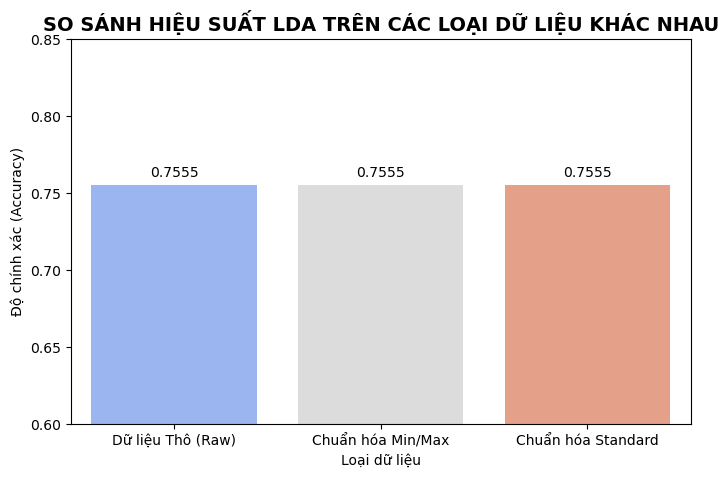

['lda_pima.pkl']

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

# Khởi tạo mô hình LDA
lda_model = LinearDiscriminantAnalysis()

# 1. Chạy trên dữ liệu Thô (Raw)
lda_model.fit(X_train_raw, y_train)
acc_raw_lda = accuracy_score(y_test, lda_model.predict(X_test_raw))

# 2. Chạy trên dữ liệu Min/Max
lda_model.fit(X_train_minmax, y_train)
acc_minmax_lda = accuracy_score(y_test, lda_model.predict(X_test_minmax))

# 3. Chạy trên dữ liệu Standard
lda_model.fit(X_train_std, y_train)
acc_std_lda = accuracy_score(y_test, lda_model.predict(X_test_std))

# --- TÓM TẮT VÀ TRÌNH DIỄN KẾT QUẢ LDA ---
results_lda = pd.DataFrame({
    'Loại dữ liệu': ['Dữ liệu Thô (Raw)', 'Chuẩn hóa Min/Max', 'Chuẩn hóa Standard'],
    'Accuracy (Tập Test)': [acc_raw_lda, acc_minmax_lda, acc_std_lda]
})

print("BẢNG TÓM TẮT KẾT QUẢ LDA:")
display.display(results_lda)

# Vẽ biểu đồ trình diễn
plt.figure(figsize=(8, 5))
sns.barplot(x='Loại dữ liệu', y='Accuracy (Tập Test)', data=results_lda, palette='coolwarm')
plt.title('SO SÁNH HIỆU SUẤT LDA TRÊN CÁC LOẠI DỮ LIỆU KHÁC NHAU', fontsize=14, fontweight='bold')
plt.ylabel('Độ chính xác (Accuracy)')
plt.ylim(0.60, 0.85)
for index, row in results_lda.iterrows():
    plt.text(index, row['Accuracy (Tập Test)'] + 0.005, f"{row['Accuracy (Tập Test)']:.4f}", color='black', ha="center")
plt.show()

# Lưu mô hình (Tùy chọn)
import joblib
joblib.dump(lda_model, 'lda_pima.pkl')

In [38]:
!jupyter nbconvert --to html Linear_Discrimination.ipynb

[NbConvertApp] Converting notebook Linear_Discrimination.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 1 image(s).
[NbConvertApp] Writing 354006 bytes to Linear_Discrimination.html
